In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [ ]:
dataset = pd.read_csv('bench.csv')
dataset


FileNotFoundError: [Errno 2] No such file or directory: 'benchmark_datasets/result_experiment_500.csv'

In [7]:
! ls benchmark_datasets

100.csv  1000.csv  10000.csv  500.csv  5000.csv  50000.csv


In [3]:
np.log(4)

1.3862943611198906

NameError: name 'scenarios' is not defined

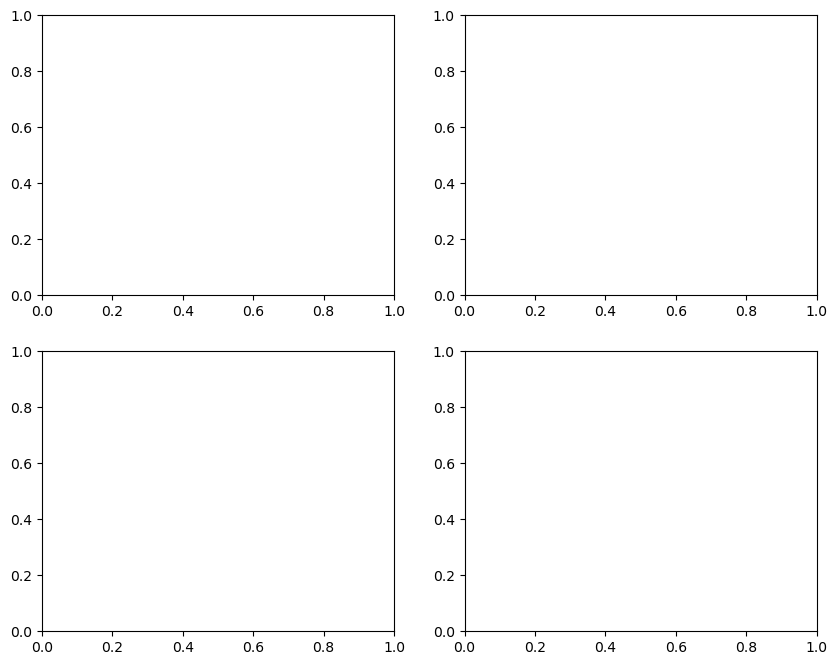

In [3]:
# Create subplots for all four scenarios in black
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Define the positions of the subplots
scenario_list = list(scenarios)

for i, ax in enumerate(axes.flat):
    if i < len(scenario_list):
        scenario = scenario_list[i]
        df_scenario = df_wce[df_wce['scenario_name'] == scenario]

        # Extract time series values (t1 to t180)
        time_values = df_scenario.iloc[:, df_scenario.columns.get_loc('t1'):df_scenario.columns.get_loc('t180') + 1]

        # Plot each row as a line in black
        for _, row in time_values.iterrows():
            ax.plot(range(1, 181), row, color='black', alpha=0.5, linewidth=0.5)

        ax.set_xlabel("u - t")
        ax.set_ylabel("Value")
        ax.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()



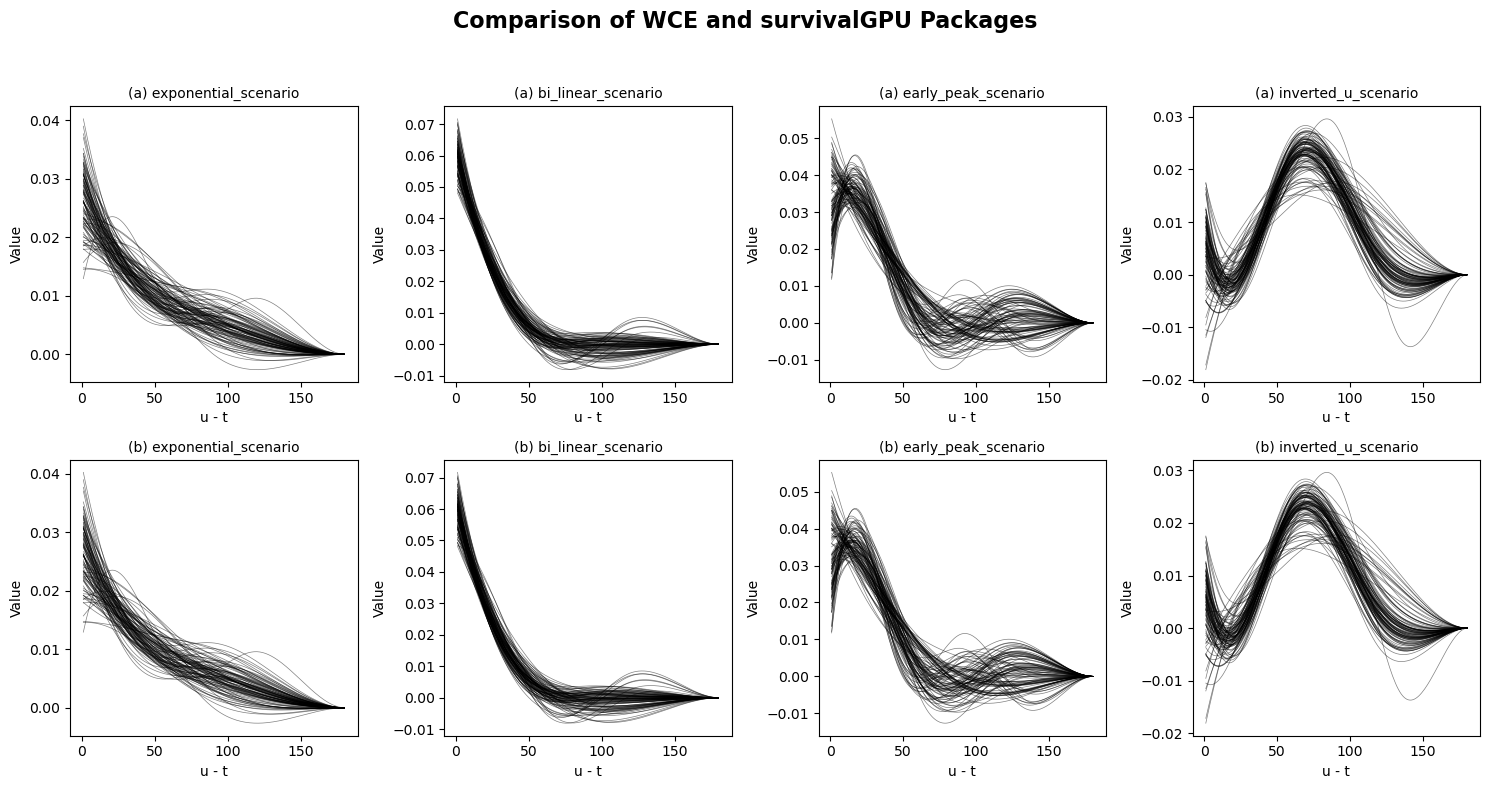

In [4]:
df = dataset

# Filter dataset for 'WCE' and 'survivalGPU' libraries
df_wce = df[df['library'] == 'WCE']
df_gpu = df[df['library'] == 'survivalGPU']

# Get unique scenarios (assuming they are the same for both libraries)
scenarios = df_wce['scenario_name'].unique()

# Create figure with two sets of 2x2 subplots
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

# Titles for each package
fig.suptitle("Comparison of WCE and survivalGPU Packages", fontsize=16, fontweight='bold')

# Loop through each scenario and create the plots
for i, scenario in enumerate(scenarios):
    # WCE plots (Left side)
    df_scenario_wce = df_wce[df_wce['scenario_name'] == scenario]
    time_values_wce = df_scenario_wce.iloc[:, df_scenario_wce.columns.get_loc('t1'):df_scenario_wce.columns.get_loc('t180') + 1]

    ax = axes[0, i]  # Upper row for WCE
    for _, row in time_values_wce.iterrows():
        ax.plot(range(1, 181), row, color='black', alpha=0.5, linewidth=0.5)
    ax.set_xlabel("u - t")
    ax.set_ylabel("Value")
    ax.set_title(f"(a) {scenario}", fontsize=10)

    # survivalGPU plots (Right side)
    df_scenario_gpu = df_gpu[df_gpu['scenario_name'] == scenario]
    time_values_gpu = df_scenario_gpu.iloc[:, df_scenario_gpu.columns.get_loc('t1'):df_scenario_gpu.columns.get_loc('t180') + 1]

    ax = axes[1, i]  # Lower row for survivalGPU
    for _, row in time_values_gpu.iterrows():
        ax.plot(range(1, 181), row, color='black', alpha=0.5, linewidth=0.5)
    ax.set_xlabel("u - t")
    ax.set_ylabel("Value")
    ax.set_title(f"(b) {scenario}", fontsize=10)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


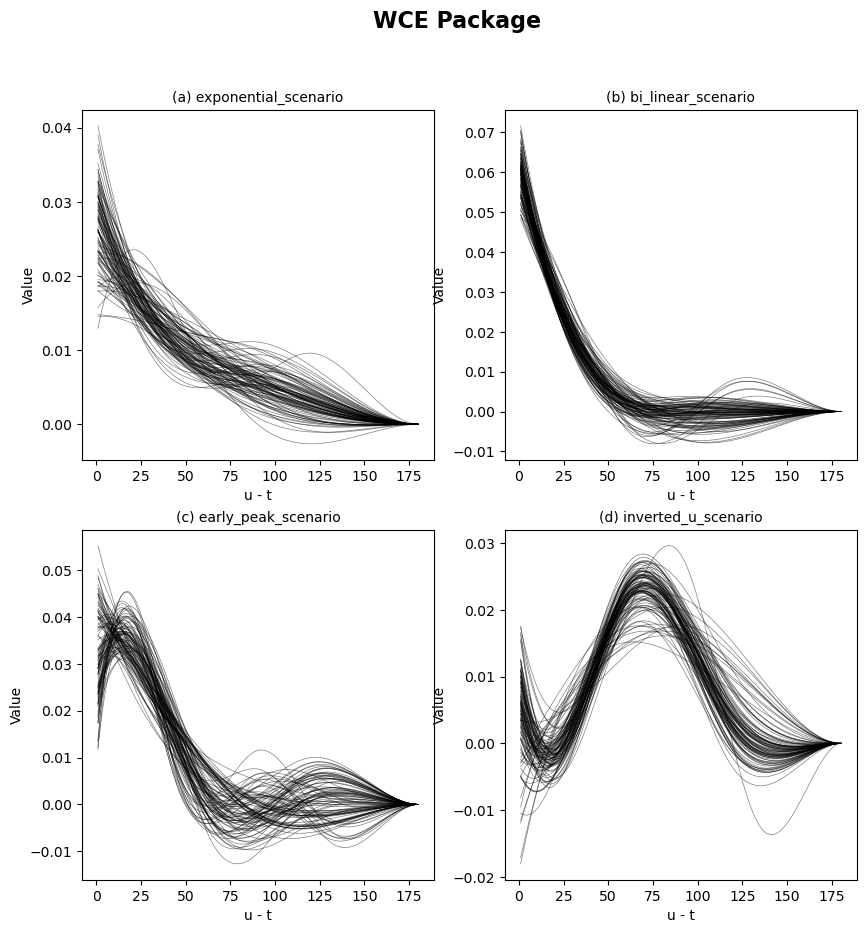

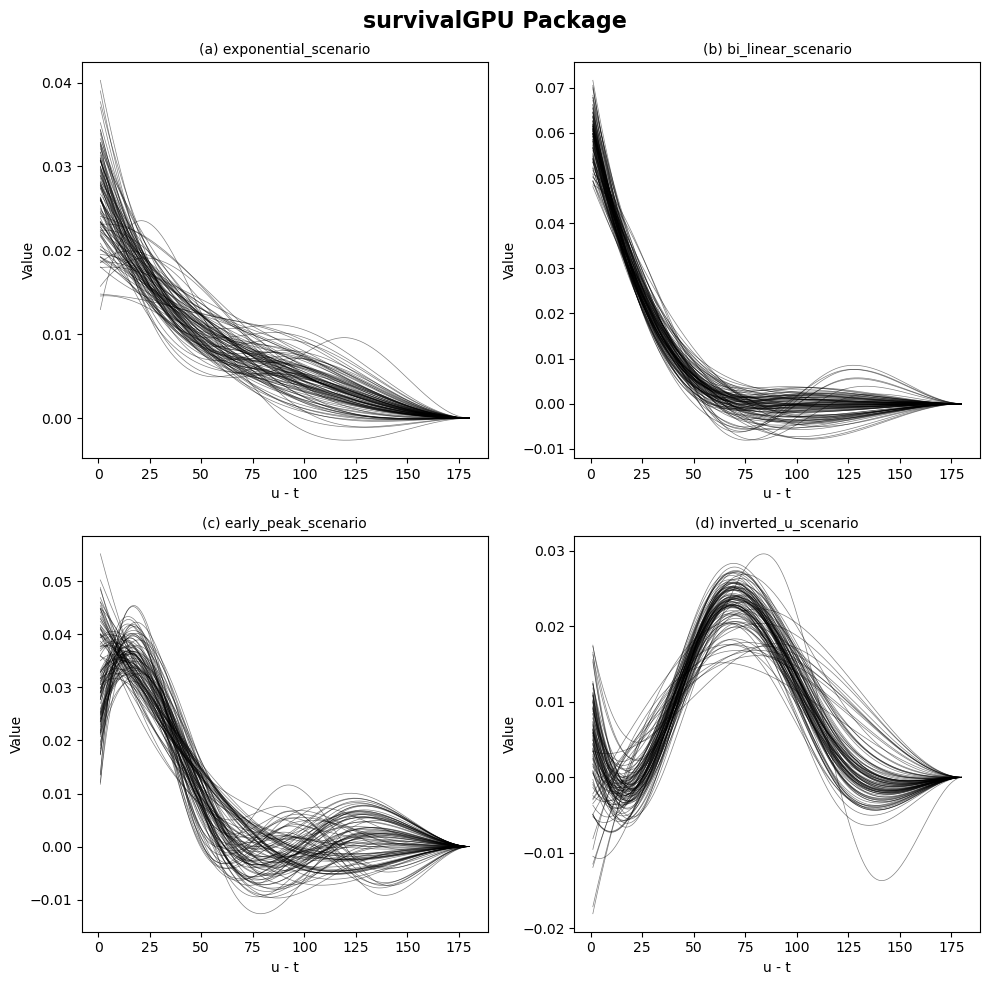

In [5]:
# Create separate figures for WCE and survivalGPU

# Figure for WCE package
fig_wce, axes_wce = plt.subplots(2, 2, figsize=(10, 10))
fig_wce.suptitle("WCE Package", fontsize=16, fontweight='bold')

# Figure for survivalGPU package
fig_gpu, axes_gpu = plt.subplots(2, 2, figsize=(10, 10))
fig_gpu.suptitle("survivalGPU Package", fontsize=16, fontweight='bold')

# Plot WCE scenarios
for i, scenario in enumerate(scenarios):
    df_scenario_wce = df_wce[df_wce['scenario_name'] == scenario]
    time_values_wce = df_scenario_wce.iloc[:, df_scenario_wce.columns.get_loc('t1'):df_scenario_wce.columns.get_loc('t180') + 1]

    ax_wce = axes_wce[i // 2, i % 2]  # Arrange in a 2x2 grid
    for _, row in time_values_wce.iterrows():
        ax_wce.plot(range(1, 181), row, color='black', alpha=0.5, linewidth=0.5)
    ax_wce.set_xlabel("u - t")
    ax_wce.set_ylabel("Value")
    ax_wce.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)



# Plot survivalGPU scenarios
for i, scenario in enumerate(scenarios):
    df_scenario_gpu = df_gpu[df_gpu['scenario_name'] == scenario]
    time_values_gpu = df_scenario_gpu.iloc[:, df_scenario_gpu.columns.get_loc('t1'):df_scenario_gpu.columns.get_loc('t180') + 1]

    ax_gpu = axes_gpu[i // 2, i % 2]  # Arrange in a 2x2 grid
    for _, row in time_values_gpu.iterrows():
        ax_gpu.plot(range(1, 181), row, color='black', alpha=0.5, linewidth=0.5)
    ax_gpu.set_xlabel("u - t")
    ax_gpu.set_ylabel("Value")
    ax_gpu.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)

# Adjust layouts
plt.tight_layout()
plt.show()







In [6]:
from pathlib import Path

# Define the save path
slide_path = Path("/home/apoirotb/dev/Inria/Notes/Slides/")
prez_name = "Point_emmanuel_bacry"

# Ensure the directory exists
save_dir = slide_path / prez_name / "images"
save_dir.mkdir(parents=True, exist_ok=True)

# Save WCE figure
image_name_wce = "wce_plot.png"
image_path_wce = save_dir / image_name_wce
fig_wce.patch.set_alpha(0.0)
fig_wce.savefig(image_path_wce, transparent=True)

# Save survivalGPU figure
image_name_gpu = "survivalgpu_plot.png"
image_path_gpu = save_dir / image_name_gpu
fig_gpu.patch.set_alpha(0.0)
fig_gpu.savefig(image_path_gpu, transparent=True)

# Confirm the save paths
image_path_wce, image_path_gpu


(PosixPath('/home/apoirotb/dev/Inria/Notes/Slides/Point_emmanuel_bacry/images/wce_plot.png'),
 PosixPath('/home/apoirotb/dev/Inria/Notes/Slides/Point_emmanuel_bacry/images/survivalgpu_plot.png'))

(PosixPath('/home/apoirotb/dev/Inria/Notes/Slides/Point_emmanuel_bacry/images/wce_plot.png'),
 PosixPath('/home/apoirotb/dev/Inria/Notes/Slides/Point_emmanuel_bacry/images/survivalgpu_plot.png'))

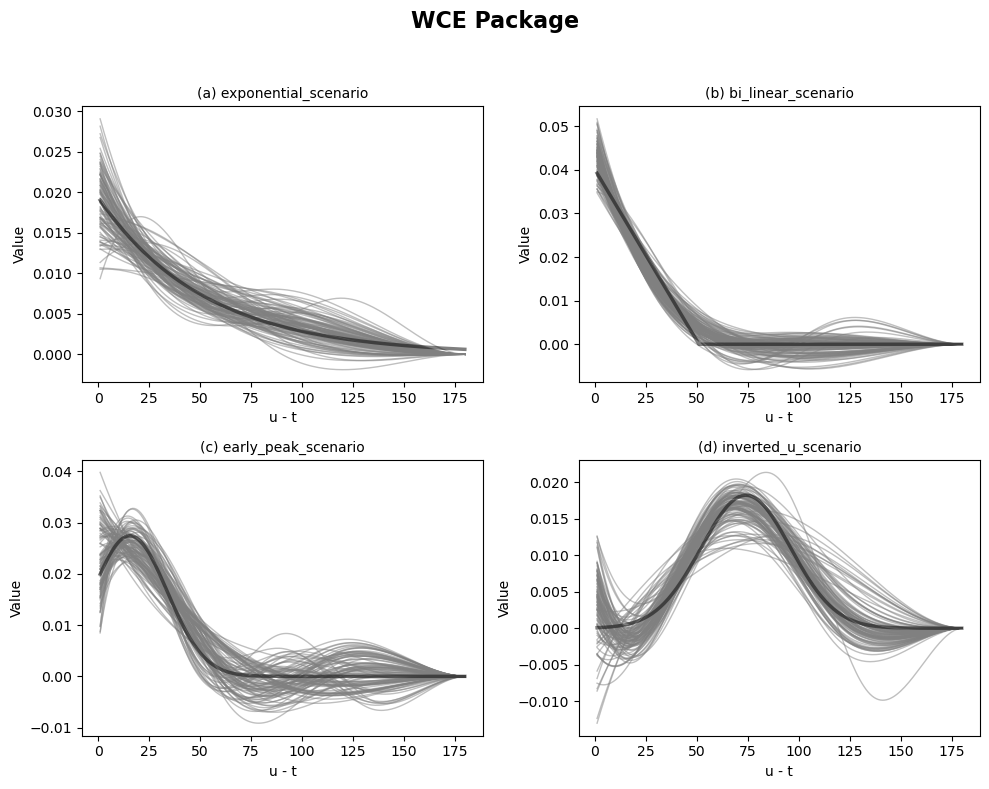

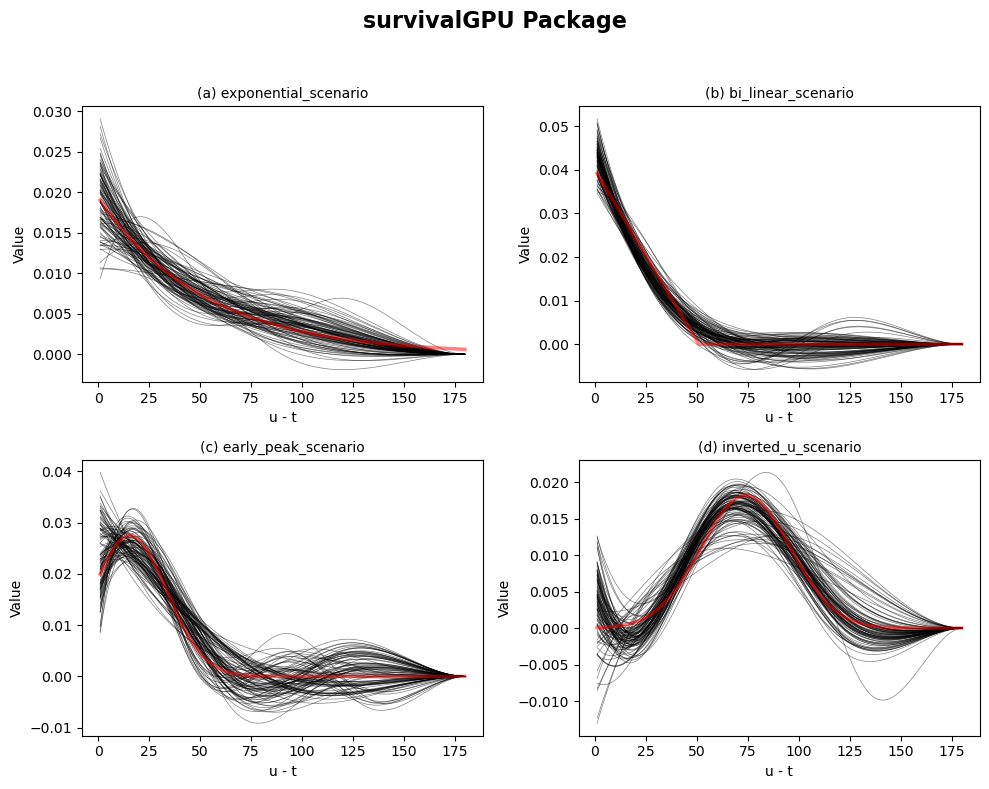

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = dataset


# Filter dataset for 'WCE' and 'survivalGPU' libraries
df_wce = df[df['library'] == 'WCE']
df_gpu = df[df['library'] == 'survivalGPU']

# Get unique scenarios (assuming they are the same for both libraries)
scenarios = df_wce['scenario_name'].unique()

# Set fixed figure size
fig_size = (10, 8)

# Create figure for WCE package
fig_wce, axes_wce = plt.subplots(2, 2, figsize=fig_size)
fig_wce.suptitle("WCE Package", fontsize=16, fontweight='bold')

# Create figure for survivalGPU package
fig_gpu, axes_gpu = plt.subplots(2, 2, figsize=fig_size)
fig_gpu.suptitle("survivalGPU Package", fontsize=16, fontweight='bold')

# Plot WCE scenarios
for i, scenario in enumerate(scenarios):
    df_scenario_wce = df_wce[df_wce['scenario_name'] == scenario]
    real_scenario = get_scenario(scenario_name = scenario , max_time = 180)
    time_values_wce = df_scenario_wce.iloc[:, df_scenario_wce.columns.get_loc('t1'):df_scenario_wce.columns.get_loc('t180') + 1]

    ax_wce = axes_wce[i // 2, i % 2]  # Arrange in a 2x2 grid
    for _, row in time_values_wce.iterrows():
        ax_wce.plot(range(1, 181), row/np.log(4), color='grey', alpha=0.5, linewidth=1)
    ax_wce.plot(range(1, 181), real_scenario, color='black', alpha=0.5, linewidth=2.5)
    ax_wce.set_xlabel("u - t")
    ax_wce.set_ylabel("Value")
    ax_wce.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)

# Plot survivalGPU scenarios
for i, scenario in enumerate(scenarios):
    df_scenario_gpu = df_gpu[df_gpu['scenario_name'] == scenario]
    time_values_gpu = df_scenario_gpu.iloc[:, df_scenario_gpu.columns.get_loc('t1'):df_scenario_gpu.columns.get_loc('t180') + 1]

    ax_gpu = axes_gpu[i // 2, i % 2]  # Arrange in a 2x2 grid
    real_scenario = get_scenario(scenario_name = scenario , max_time = 180)
    for _, row in time_values_gpu.iterrows():
        ax_gpu.plot(range(1, 181), row/np.log(4), color='black', alpha=0.5, linewidth=0.5)
    ax_gpu.plot(range(1, 181), real_scenario, color='red', alpha=0.5, linewidth=2.5)
    ax_gpu.set_xlabel("u - t")
    ax_gpu.set_ylabel("Value")
    ax_gpu.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)

# Adjust layout to ensure consistency
fig_wce.tight_layout(rect=[0, 0, 1, 0.95])
fig_gpu.tight_layout(rect=[0, 0, 1, 0.95])

# Define the save path
slide_path = Path("/home/apoirotb/dev/Inria/Notes/Slides/")
prez_name = "Point_emmanuel_bacry"

# Ensure the directory exists (create only if permissions allow)
save_dir = slide_path / prez_name / "images"
try:
    save_dir.mkdir(parents=True, exist_ok=True)
except PermissionError:
    print("Permission denied: Unable to create directory. Saving locally instead.")
    save_dir = Path(".")  # Save locally if directory creation fails

# Save WCE figure
image_name_wce = "wce_plot.png"
image_path_wce = save_dir / image_name_wce
fig_wce.patch.set_alpha(0.0)
fig_wce.savefig(image_path_wce, transparent=True, dpi=300)

# Save survivalGPU figure
image_name_gpu = "survivalgpu_plot.png"
image_path_gpu = save_dir / image_name_gpu
fig_gpu.patch.set_alpha(0.0)
fig_gpu.savefig(image_path_gpu, transparent=True, dpi=300)

# Confirm save paths
image_path_wce, image_path_gpu


In [ ]:
wce_data = dataset.iloc[:,10:]

# dataset[sum] = dataset.iloc[:,10:].sum(axis=1)

wce_data['sum'] = wce_data.sum(axis=1)
wce_data["sum"]


0      0.947972
1      0.947972
2      0.882507
3      0.882507
4      1.337004
         ...   
795    1.480028
796    1.768605
797    1.768605
798    1.478183
799    1.478183
Name: sum, Length: 800, dtype: float64

In [8]:
from scipy.stats import norm



def exponential_scenario(u_t, name = False):
    return((7 * np.exp(-7*u_t/365))) # divide by 365 in order to have a t in days

def bi_linear_scenario(u_t):
    if u_t < 50:
        return (1- (u_t/365)/(50/365))
    return 0 

def early_peak_scenario(u_t):
    return norm.pdf(u_t/365, 0.04, 0.05)


def inverted_u_scenario(u_t):
    return norm.pdf(u_t/365, 0.2, 0.06)

def constant_scenario(u_t):
    if u_t <= 180:
        return 1/180
    else:
        return 0
    
def hat_scenario(u_t):
    if u_t < 180:
        return (u_t/180)
    elif (u_t >= 180) and (u_t < 240):
        return 1
    else: 
        return (1 - (u_t-240)/180)






def get_scenario(scenario_name: int, max_time: int):
    """
    Get the scenario list based on the given scenario name and maximum time.

    Parameters:
    - scenario_name (int): The name of the scenario to retrieve.
    - max_time (int): The maximum time for which to clear the scenario list.
    Returns:
    - scenario_list (numpy.ndarray): The generated scenario list.

    Raises:
    - ValueError: If the given scenario name is not defined in the scenario list.

    """

    scenario_list = {
        "exponential_scenario": exponential_scenario,
        "bi_linear_scenario": bi_linear_scenario,
        "early_peak_scenario": early_peak_scenario,
        "inverted_u_scenario": inverted_u_scenario,
    }

    try:
        scenario_function = scenario_list[scenario_name]
    except KeyError:
        raise ValueError(f"The scenario '{scenario_name}' is not defined")

    scenario_list = []
    normalization_factor = 0

    for i in range(0, 365):
        normalization_factor += scenario_function(i)

    for i in range(0, max_time):
        scenario_list.append(scenario_function(i))

    scenario_list = np.array(scenario_list)

    return scenario_list / normalization_factor

In [9]:
get_scenario(scenario_name = "exponential_scenario", max_time = 180)


array([0.01901269, 0.01865154, 0.01829724, 0.01794968, 0.01760872,
       0.01727424, 0.01694611, 0.01662421, 0.01630843, 0.01599864,
       0.01569474, 0.01539662, 0.01510415, 0.01481724, 0.01453578,
       0.01425967, 0.0139888 , 0.01372308, 0.01346241, 0.01320668,
       0.01295582, 0.01270972, 0.01246829, 0.01223145, 0.01199911,
       0.01177119, 0.01154759, 0.01132824, 0.01111305, 0.01090196,
       0.01069487, 0.01049172, 0.01029242, 0.01009692, 0.00990512,
       0.00971697, 0.00953239, 0.00935132, 0.00917369, 0.00899943,
       0.00882848, 0.00866078, 0.00849627, 0.00833488, 0.00817656,
       0.00802124, 0.00786887, 0.0077194 , 0.00757277, 0.00742892,
       0.00728781, 0.00714937, 0.00701357, 0.00688034, 0.00674965,
       0.00662144, 0.00649566, 0.00637227, 0.00625123, 0.00613248,
       0.00601599, 0.00590172, 0.00578961, 0.00567964, 0.00557175,
       0.00546591, 0.00536209, 0.00526023, 0.00516031, 0.00506229,
       0.00496613, 0.0048718 , 0.00477926, 0.00468847, 0.00459

In [ ]:
analytics_df = dataset.iloc[:,:10]


In [ ]:
# grouped_analytics_df = analytics_df.groupby(["scenario_name","library"])


analytics_df = dataset.iloc[:,:10]


analytics_df["beta"] = np.log(analytics_df["simulated_HR"])

analytics_df["target_beta"] = np.log(analytics_df["HR_target"])




# Group by 'scenario_name' and 'library' and calculate the mean and std of 'HR' and mean of 'computation_time'
grouped_analytics_df = analytics_df.groupby(['scenario_name', 'library']).agg(
    mean_beta=('beta', 'mean'),
    std_beta=('beta', 'std'),
    target_beta=('target_beta', 'first'),
    mean_computation_time=('computation_time', 'mean')
).reset_index()



grouped_analytics_df["biais (%)"] = round((grouped_analytics_df["mean_beta"] - grouped_analytics_df["target_beta"]) / grouped_analytics_df["target_beta"] * 100, 2)
grouped_analytics_df["std_beta"] = round(grouped_analytics_df["std_beta"], 3)
grouped_analytics_df["mean_beta"] = round(grouped_analytics_df["mean_beta"], 3)
grouped_analytics_df["target_beta"] = round(grouped_analytics_df["target_beta"], 3)
grouped_analytics_df["mean_computation_time"] = round(grouped_analytics_df["mean_computation_time"], 2)



WCE_df = grouped_analytics_df[grouped_analytics_df["library"] == "WCE"]
survivalGPU_df = grouped_analytics_df[grouped_analytics_df["library"] == "survivalGPU"]

WCE_df = WCE_df.drop(columns = ["library"])
survivalGPU_df = survivalGPU_df.drop(columns = ["library"])


WCE_df = WCE_df.rename(columns = {"mean_beta": "mean_beta_WCE", "std_beta": "std_beta_WCE", "target_beta": "target_beta_WCE", "mean_computation_time": "mean_computation_time_WCE", "biais (%)": "biais (%) WCE"})
survivalGPU_df = survivalGPU_df.rename(columns = {"mean_beta": "mean_beta_survivalGPU", "std_beta": "std_beta_survivalGPU", "target_beta": "target_beta_survivalGPU", "mean_computation_time": "mean_computation_time_survivalGPU", "biais (%)": "biais (%) survivalGPU"})

combined_df = pd.merge(WCE_df, survivalGPU_df, on = "scenario_name")
combined_df



result_for_latex = combined_df 
result_for_latex = result_for_latex.drop(columns = ["target_beta_survivalGPU"])

result_for_latex["scenario_name"]= [
    "Exponential",
    "Bi-linear",
    "Early peak",
    "Inverted U",
]

result_for_latex = result_for_latex[['scenario_name', 
                                     'target_beta_WCE',
                                     'mean_beta_WCE', 
                                     'std_beta_WCE', ''
                                     'biais (%) WCE', 
                                     'mean_computation_time_WCE', 
                                     'mean_beta_survivalGPU', 
                                     'std_beta_survivalGPU', 
                                     'biais (%) survivalGPU',
                                     'mean_computation_time_survivalGPU']]

result_for_latex


In [ ]:
grouped_analytics_df



,scenario_name,library,mean_beta,std_beta,target_beta,mean_computation_time,biais (%)
0,inverted_u_scenario,WCE,1.375,0.067,1.386,79.82,-0.82
1,inverted_u_scenario,survivalGPU,1.375,0.067,1.386,4.56,-0.82


In [ ]:
WCE_df = grouped_analytics_df[grouped_analytics_df["library"] == "WCE"]
survivalGPU_df = grouped_analytics_df[grouped_analytics_df["library"] == "survivalGPU"]

WCE_df = WCE_df.drop(columns = ["library"])
survivalGPU_df = survivalGPU_df.drop(columns = ["library"])


WCE_df = WCE_df.rename(columns = {"mean_beta": "mean_beta_WCE", "std_beta": "std_beta_WCE", "target_beta": "target_beta_WCE", "mean_computation_time": "mean_computation_time_WCE", "biais (%)": "biais (%) WCE"})
survivalGPU_df = survivalGPU_df.rename(columns = {"mean_beta": "mean_beta_survivalGPU", "std_beta": "std_beta_survivalGPU", "target_beta": "target_beta_survivalGPU", "mean_computation_time": "mean_computation_time_survivalGPU", "biais (%)": "biais (%) survivalGPU"})

combined_df = pd.merge(WCE_df, survivalGPU_df, on = "scenario_name")
combined_df


,scenario_name,mean_beta_WCE,std_beta_WCE,target_beta_WCE,mean_computation_time_WCE,biais (%) WCE,mean_beta_survivalGPU,std_beta_survivalGPU,target_beta_survivalGPU,mean_computation_time_survivalGPU,biais (%) survivalGPU
0,bi_linear_scenario,1.351,0.207,1.386,2.61,-2.54,1.351,0.207,1.386,2.08,-2.54
1,early_peak_scenario,1.437,0.243,1.386,2.57,3.65,1.437,0.243,1.386,2.08,3.65
2,exponential_scenario,1.349,0.196,1.386,2.71,-2.68,1.349,0.196,1.386,2.08,-2.67
3,inverted_u_scenario,1.369,0.230,1.386,2.57,-1.21,1.370,0.230,1.386,2.07,-1.20


In [ ]:
result_for_latex = combined_df 
result_for_latex = result_for_latex.drop(columns = ["target_beta_survivalGPU"])

result_for_latex["scenario_name"]= [
    "Exponential",
    "Bi-linear",
    "Early peak",
    "Inverted U",
]

result_for_latex = result_for_latex[['scenario_name', 
                                     'target_beta_WCE',
                                     'mean_beta_WCE', 
                                     'std_beta_WCE', ''
                                     'biais (%) WCE', 
                                     'mean_computation_time_WCE', 
                                     'mean_beta_survivalGPU', 
                                     'std_beta_survivalGPU', 
                                     'biais (%) survivalGPU',
                                     'mean_computation_time_survivalGPU']]

result_for_latex

,scenario_name,target_beta_WCE,mean_beta_WCE,std_beta_WCE,biais (%) WCE,mean_computation_time_WCE,mean_beta_survivalGPU,std_beta_survivalGPU,biais (%) survivalGPU,mean_computation_time_survivalGPU
0,Exponential,1.386,1.351,0.207,-2.54,2.61,1.351,0.207,-2.54,2.08
1,Bi-linear,1.386,1.437,0.243,3.65,2.57,1.437,0.243,3.65,2.08
2,Early peak,1.386,1.349,0.196,-2.68,2.71,1.349,0.196,-2.67,2.08
3,Inverted U,1.386,1.369,0.230,-1.21,2.57,1.370,0.230,-1.20,2.07


In [ ]:
latex_code = result_for_latex.to_latex(index=False, column_format="|l|c|c|c|c|c|c|c|c|c|c|", float_format="%.3f")
print(latex_code)

\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|}
\toprule
scenario_name & target_beta_WCE & mean_beta_WCE & std_beta_WCE & biais (%) WCE & mean_computation_time_WCE & mean_beta_survivalGPU & std_beta_survivalGPU & biais (%) survivalGPU & mean_computation_time_survivalGPU \\
\midrule
Exponential & 1.386 & 1.351 & 0.207 & -2.540 & 2.610 & 1.351 & 0.207 & -2.540 & 2.080 \\
Bi-linear & 1.386 & 1.437 & 0.243 & 3.650 & 2.570 & 1.437 & 0.243 & 3.650 & 2.080 \\
Early peak & 1.386 & 1.349 & 0.196 & -2.680 & 2.710 & 1.349 & 0.196 & -2.670 & 2.080 \\
Inverted U & 1.386 & 1.369 & 0.230 & -1.210 & 2.570 & 1.370 & 0.230 & -1.200 & 2.070 \\
\bottomrule
\end{tabular}



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|}
\toprule
scenario_name & mean_beta_WCE & std_beta_WCE & target_beta_WCE & mean_computation_time_WCE & biais (%) WCE & mean_beta_survivalGPU & std_beta_survivalGPU & target_beta_survivalGPU & mean_computation_time_survivalGPU & biais (%) survivalGPU \\
\midrule
bi_linear_scenario & 1.351 & 0.207 & 1.386 & 2.610 & -2.540 & 1.351 & 0.207 & 1.386 & 2.080 & -2.540 \\
early_peak_scenario & 1.437 & 0.243 & 1.386 & 2.570 & 3.650 & 1.437 & 0.243 & 1.386 & 2.080 & 3.650 \\
exponential_scenario & 1.349 & 0.196 & 1.386 & 2.710 & -2.680 & 1.349 & 0.196 & 1.386 & 2.080 & -2.670 \\
inverted_u_scenario & 1.369 & 0.230 & 1.386 & 2.570 & -1.210 & 1.370 & 0.230 & 1.386 & 2.070 & -1.200 \\
\bottomrule
\end{tabular}

\begin{table}[h]
    \centering
    \caption{Estimated $\beta$ from simulations for each of the weight function scenarios}
    \begin{tabular}{|l|c|c|c|c|c|c|c|}
        \cline{3-8}
        \multicolumn{2}{c|}{} & \multicolumn{3}{c|}{CPU} & \multicolumn{3}{c|}{GPU} \\
        \hline
        Weight & True $\beta$ & mean($\beta$) & SD($\beta$) & \% Bias & mean($\beta$) & SD($\beta$) & \% Bias \\
        \hline
        Exponential & 1.351 & 0.207 & 1.386 & 2.610 & -2.540 & 1.351 & 0.207 & 1.386 & 2.080 & -2.540 \\
        Bi-linear   & 1.437 & 0.243 & 1.386 & 2.570 & 3.650 & 1.437 & 0.243 & 1.386 &  2.080 & 3.650 \\
        Early peak  & 1.349 & 0.196 & 1.386 & 2.710 & -2.680 & 1.349 & 0.196 & 1.386 & 2.080 & -2.670 \\
        Inverted U  & 1.369 & 0.230 & 1.386 & 2.570 & -1.210 & 1.370 & 0.230 & 1.386 & 2.070 & -1.200 \\
        \hline
    \end{tabular}
\end{table}

In [ ]:
dataset_5000 = pd.read_csv('result_experiment_5000.csv')
dataset_5000


,Unnamed: 0,iteration,library,scenario_name,HR_target,computation_time,simulated_HR,beta,biais_beta,BIC,...,t171,t172,t173,t174,t175,t176,t177,t178,t179,t180
0,1,1,WCE,exponential_scenario,4,84.155079,3.633836,1.290289,-6.925341,54998.319221,...,0.000088,0.000071,0.000055,0.000042,0.000030,0.000020,0.000012,0.000006,0.000002,3.352047e-07
1,2,1,survivalGPU,exponential_scenario,4,5.289926,3.633838,1.290289,-6.925288,54998.318414,...,0.000088,0.000071,0.000055,0.000042,0.000030,0.000020,0.000012,0.000006,0.000002,3.352020e-07
2,3,2,WCE,exponential_scenario,4,79.293805,3.310251,1.197024,-13.652960,55488.937951,...,0.000040,0.000032,0.000025,0.000019,0.000013,0.000009,0.000005,0.000003,0.000001,1.452654e-07
3,4,2,survivalGPU,exponential_scenario,4,4.500609,3.310248,1.197023,-13.653029,55488.932931,...,0.000040,0.000032,0.000025,0.000019,0.000013,0.000009,0.000005,0.000003,0.000001,1.452606e-07
4,5,3,WCE,exponential_scenario,4,81.607251,3.959574,1.376136,-0.732746,54428.632728,...,0.000113,0.000091,0.000071,0.000054,0.000039,0.000026,0.000016,0.000008,0.000003,4.342860e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,98,survivalGPU,inverted_u_scenario,4,4.284089,3.972333,1.379354,-0.500671,54346.451342,...,-0.000164,-0.000136,-0.000109,-0.000084,-0.000062,-0.000043,-0.000027,-0.000014,-0.000005,-7.639111e-07
796,797,99,WCE,inverted_u_scenario,4,79.488210,3.945837,1.372661,-0.983426,54402.172917,...,-0.000139,-0.000115,-0.000092,-0.000072,-0.000053,-0.000037,-0.000023,-0.000012,-0.000005,-6.565796e-07
797,798,99,survivalGPU,inverted_u_scenario,4,4.496636,3.945843,1.372663,-0.983319,54402.177904,...,-0.000139,-0.000115,-0.000092,-0.000072,-0.000053,-0.000037,-0.000023,-0.000012,-0.000005,-6.565723e-07
798,799,100,WCE,inverted_u_scenario,4,79.629646,3.997896,1.385768,-0.037959,54349.470206,...,-0.000133,-0.000110,-0.000089,-0.000069,-0.000051,-0.000035,-0.000022,-0.000012,-0.000004,-6.344760e-07


(PosixPath('/home/apoirotb/dev/Inria/Notes/Slides/Point_emmanuel_bacry/images/wce_plot_5000.png'),
 PosixPath('/home/apoirotb/dev/Inria/Notes/Slides/Point_emmanuel_bacry/images/survivalgpu_plot_5000.png'))

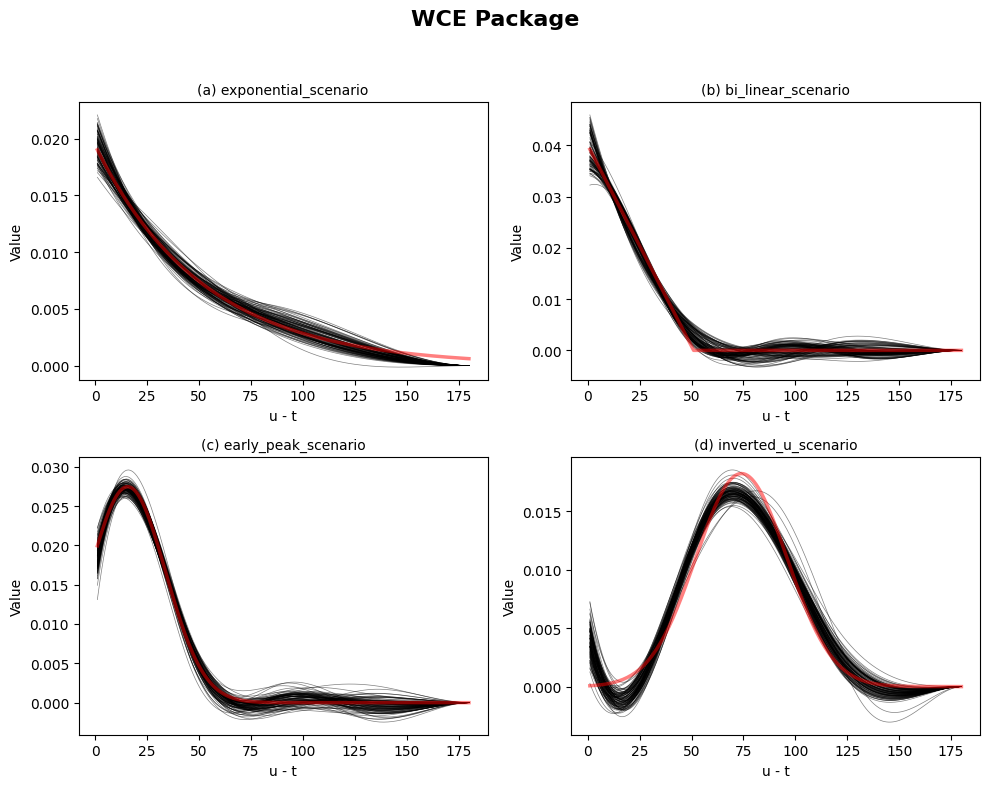

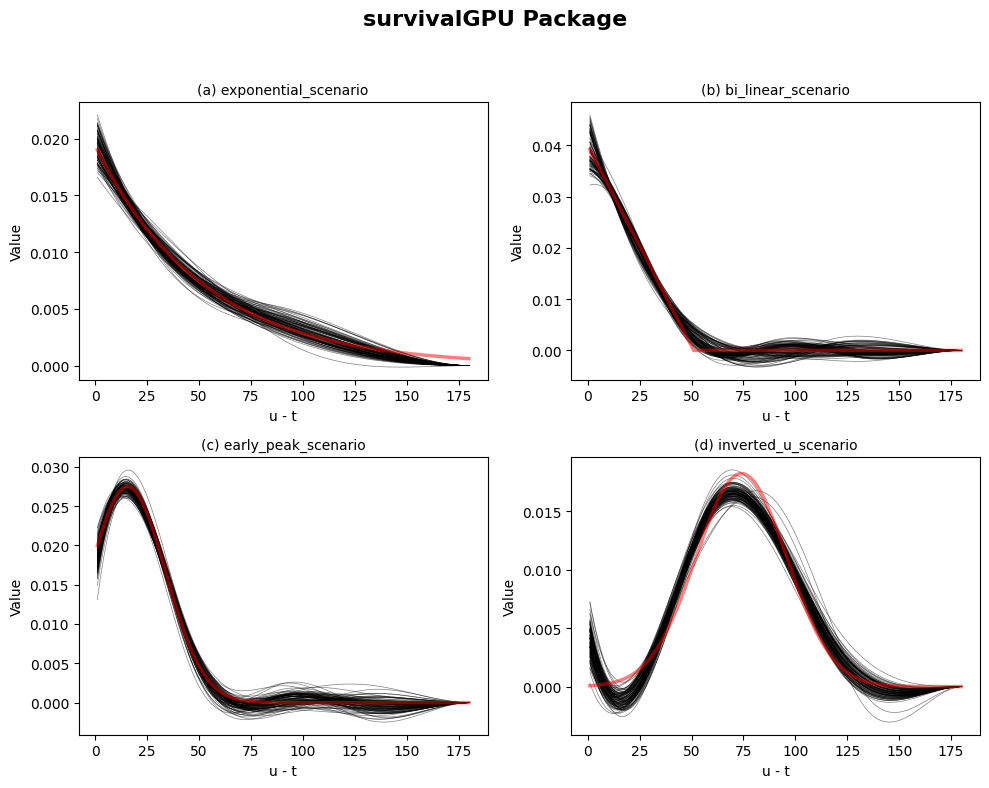

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = dataset_5000



# Filter dataset for 'WCE' and 'survivalGPU' libraries
df_wce = df[df['library'] == 'WCE']
df_gpu = df[df['library'] == 'survivalGPU']

# Get unique scenarios (assuming they are the same for both libraries)
scenarios = df_wce['scenario_name'].unique()

# Set fixed figure size
fig_size = (10, 8)

# Create figure for WCE package
fig_wce, axes_wce = plt.subplots(2, 2, figsize=fig_size)
fig_wce.suptitle("WCE Package", fontsize=16, fontweight='bold')

# Create figure for survivalGPU package
fig_gpu, axes_gpu = plt.subplots(2, 2, figsize=fig_size)
fig_gpu.suptitle("survivalGPU Package", fontsize=16, fontweight='bold')

# Plot WCE scenarios
for i, scenario in enumerate(scenarios):
    df_scenario_wce = df_wce[df_wce['scenario_name'] == scenario]
    real_scenario = get_scenario(scenario_name = scenario , max_time = 180)
    time_values_wce = df_scenario_wce.iloc[:, df_scenario_wce.columns.get_loc('t1'):df_scenario_wce.columns.get_loc('t180') + 1]

    ax_wce = axes_wce[i // 2, i % 2]  # Arrange in a 2x2 grid
    for _, row in time_values_wce.iterrows():
        ax_wce.plot(range(1, 181), row/np.log(4), color='black', alpha=0.5, linewidth=0.5)
    ax_wce.plot(range(1, 181), real_scenario, color='red', alpha=0.5, linewidth=2.5)
    ax_wce.set_xlabel("u - t")
    ax_wce.set_ylabel("Value")
    ax_wce.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)

# Plot survivalGPU scenarios
for i, scenario in enumerate(scenarios):
    df_scenario_gpu = df_gpu[df_gpu['scenario_name'] == scenario]
    time_values_gpu = df_scenario_gpu.iloc[:, df_scenario_gpu.columns.get_loc('t1'):df_scenario_gpu.columns.get_loc('t180') + 1]

    ax_gpu = axes_gpu[i // 2, i % 2]  # Arrange in a 2x2 grid
    real_scenario = get_scenario(scenario_name = scenario , max_time = 180)
    for _, row in time_values_gpu.iterrows():
        ax_gpu.plot(range(1, 181), row/np.log(4), color='black', alpha=0.5, linewidth=0.5)
    ax_gpu.plot(range(1, 181), real_scenario, color='red', alpha=0.5, linewidth=2.5)
    ax_gpu.set_xlabel("u - t")
    ax_gpu.set_ylabel("Value")
    ax_gpu.set_title(f"({chr(97 + i)}) {scenario}", fontsize=10)

# Adjust layout to ensure consistency
fig_wce.tight_layout(rect=[0, 0, 1, 0.95])
fig_gpu.tight_layout(rect=[0, 0, 1, 0.95])

# Define the save path
slide_path = Path("/home/apoirotb/dev/Inria/Notes/Slides/")
prez_name = "Point_emmanuel_bacry"

# Ensure the directory exists (create only if permissions allow)
save_dir = slide_path / prez_name / "images"
try:
    save_dir.mkdir(parents=True, exist_ok=True)
except PermissionError:
    print("Permission denied: Unable to create directory. Saving locally instead.")
    save_dir = Path(".")  # Save locally if directory creation fails

# Save WCE figure
image_name_wce = "wce_plot_5000.png"
image_path_wce = save_dir / image_name_wce
fig_wce.patch.set_alpha(0.0)
fig_wce.savefig(image_path_wce, transparent=True, dpi=300)

# Save survivalGPU figure
image_name_gpu = "survivalgpu_plot_5000.png"
image_path_gpu = save_dir / image_name_gpu
fig_gpu.patch.set_alpha(0.0)
fig_gpu.savefig(image_path_gpu, transparent=True, dpi=300)

# Confirm save paths
image_path_wce, image_path_gpu


\begin{table}[h]
    \centering
    \caption{Estimated $\beta$ from simulations for each of the weight function scenarios}
    \begin{tabular}{|l|c|c|c|c|c|c|c|c|c|}
        \cline{3-10}
        \multicolumn{2}{|c|}{} & \multicolumn{4}{c|}{\textbf{WCE package}} & \multicolumn{4}{c|}{\textbf{survivalGPU}} \\
        \hline
        Weight & True $\beta$ & mean($\beta$) & SD($\beta$) & \% Bias & Time (s) & mean($\beta$) & SD($\beta$) & \% Bias & Time (s) \\
        \hline
        Exponential & 1.386 & 1.351 & 0.207 & -2.540 & 2.610 & 1.351 & 0.207 & -2.540 & 2.080 \\
        Bi-linear & 1.386 & 1.437 & 0.243 & 3.650 & 2.570 & 1.437 & 0.243 & 3.650 & 2.080 \\
        Early peak & 1.386 & 1.349 & 0.196 & -2.680 & 2.710 & 1.349 & 0.196 & -2.670 & 2.080 \\
        Inverted U & 1.386 & 1.369 & 0.230 & -1.210 & 2.570 & 1.370 & 0.230 & -1.200 & 2.070 \\
        \hline
    \end{tabular}
\end{table}


In [ ]:
# grouped_analytics_df = analytics_df.groupby(["scenario_name","library"])


analytics_df = dataset_5000.iloc[:,:10]


analytics_df["beta"] = np.log(analytics_df["simulated_HR"])

analytics_df["target_beta"] = np.log(analytics_df["HR_target"])




# Group by 'scenario_name' and 'library' and calculate the mean and std of 'HR' and mean of 'computation_time'
grouped_analytics_df = analytics_df.groupby(['scenario_name', 'library']).agg(
    mean_beta=('beta', 'mean'),
    std_beta=('beta', 'std'),
    target_beta=('target_beta', 'first'),
    mean_computation_time=('computation_time', 'mean')
).reset_index()



grouped_analytics_df["biais (%)"] = round((grouped_analytics_df["mean_beta"] - grouped_analytics_df["target_beta"]) / grouped_analytics_df["target_beta"] * 100, 2)
grouped_analytics_df["std_beta"] = round(grouped_analytics_df["std_beta"], 3)
grouped_analytics_df["mean_beta"] = round(grouped_analytics_df["mean_beta"], 3)
grouped_analytics_df["target_beta"] = round(grouped_analytics_df["target_beta"], 3)
grouped_analytics_df["mean_computation_time"] = round(grouped_analytics_df["mean_computation_time"], 2)



WCE_df = grouped_analytics_df[grouped_analytics_df["library"] == "WCE"]
survivalGPU_df = grouped_analytics_df[grouped_analytics_df["library"] == "survivalGPU"]

WCE_df = WCE_df.drop(columns = ["library"])
survivalGPU_df = survivalGPU_df.drop(columns = ["library"])


WCE_df = WCE_df.rename(columns = {"mean_beta": "mean_beta_WCE", "std_beta": "std_beta_WCE", "target_beta": "target_beta_WCE", "mean_computation_time": "mean_computation_time_WCE", "biais (%)": "biais (%) WCE"})
survivalGPU_df = survivalGPU_df.rename(columns = {"mean_beta": "mean_beta_survivalGPU", "std_beta": "std_beta_survivalGPU", "target_beta": "target_beta_survivalGPU", "mean_computation_time": "mean_computation_time_survivalGPU", "biais (%)": "biais (%) survivalGPU"})

combined_df = pd.merge(WCE_df, survivalGPU_df, on = "scenario_name")
combined_df



result_for_latex = combined_df 
result_for_latex = result_for_latex.drop(columns = ["target_beta_survivalGPU"])

result_for_latex["scenario_name"]= [
    "Exponential",
    "Bi-linear",
    "Early peak",
    "Inverted U",
]

result_for_latex = result_for_latex[['scenario_name', 
                                     'target_beta_WCE',
                                     'mean_beta_WCE', 
                                     'std_beta_WCE', ''
                                     'biais (%) WCE', 
                                     'mean_computation_time_WCE', 
                                     'mean_beta_survivalGPU', 
                                     'std_beta_survivalGPU', 
                                     'biais (%) survivalGPU',
                                     'mean_computation_time_survivalGPU']]

result_for_latex


,scenario_name,target_beta_WCE,mean_beta_WCE,std_beta_WCE,biais (%) WCE,mean_computation_time_WCE,mean_beta_survivalGPU,std_beta_survivalGPU,biais (%) survivalGPU,mean_computation_time_survivalGPU
0,Exponential,1.386,1.377,0.071,-0.66,79.76,1.377,0.071,-0.65,4.53
1,Bi-linear,1.386,1.365,0.076,-1.51,79.63,1.365,0.076,-1.51,4.55
2,Early peak,1.386,1.313,0.071,-5.31,79.57,1.313,0.071,-5.30,4.51
3,Inverted U,1.386,1.373,0.064,-0.95,79.80,1.373,0.064,-0.95,4.52


In [ ]:
latex_code = result_for_latex.to_latex(index=False, column_format="|l|c|c|c|c|c|c|c|c|c|c|", float_format="%.3f")
print(latex_code)

\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|}
\toprule
scenario_name & target_beta_WCE & mean_beta_WCE & std_beta_WCE & biais (%) WCE & mean_computation_time_WCE & mean_beta_survivalGPU & std_beta_survivalGPU & biais (%) survivalGPU & mean_computation_time_survivalGPU \\
\midrule
Exponential & 1.386 & 1.377 & 0.071 & -0.660 & 79.760 & 1.377 & 0.071 & -0.650 & 4.530 \\
Bi-linear & 1.386 & 1.365 & 0.076 & -1.510 & 79.630 & 1.365 & 0.076 & -1.510 & 4.550 \\
Early peak & 1.386 & 1.313 & 0.071 & -5.310 & 79.570 & 1.313 & 0.071 & -5.300 & 4.510 \\
Inverted U & 1.386 & 1.373 & 0.064 & -0.950 & 79.800 & 1.373 & 0.064 & -0.950 & 4.520 \\
\bottomrule
\end{tabular}



In [ ]:
from .wce_features import wce_features_batch, bspline_atoms
